# Supplementary Figure S43: zebrafish attention validation

This notebook loads the packaged panel data, recalculates the displayed summaries, and saves the PDF and PNG. It does not run model training or download external data.


## Reproduction route: files passed between analysis steps

Read the steps from top to bottom. Each one names the code that runs, the files
it reads, the files it writes, and the next command that consumes those files.
Steps marked `manuscript result bundle` record the files used for the paper;
public steps can be run from this checkout.

### Step 1: calculate model and external-method evidence tables

**Paper:** S43

```text
python -m scripts.run_zebrafish_attention_validation analyze --spec <analysis-spec.json> --output-dir <attention-analysis> --n-selected-pairs 30
```

**Reads:** `manuscript zebrafish checkpoint; aligned cells; COMMOT/CellAgentChat outputs; fixed LR universe`

**Writes:** `directed-pair concordance, expression, display-edge and interaction-sensitivity tables plus analysis_manifest.json`

**Next:** `combine with JAM controls and draw S43`

**Availability:** public

### Step 2: combine JAM controls and render the formal report

**Paper:** S43

```text
python -m scripts.run_zebrafish_attention_validation report --help
```

**Reads:** `attention-analysis tables and one or more matched JAM control manifests`

**Writes:** `spatial-null, JAM, summary and panel tables; vector PDF/PNG; report_manifest.json`

**Next:** `compact public redraw`

**Availability:** public runner; `report --help` lists the matched analysis and JAM inputs

### Step 3: recalculate displayed statistics and draw

**Paper:** S43

```text
load_zebrafish_attention_results() → plot_zebrafish_attention()
```

**Reads:** `directed_pair_concordance.csv; JAM tables; spatial-null tables; expression and edge tables`

**Writes:** `zebrafish_attention_jam_validation.pdf/.png and summary tables`

**Next:** `finished figure`

**Availability:** public

## Load figure inputs


In [1]:
import pandas as pd

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

from pathlib import Path

from IPython.display import Image, display

from CytoBridge.results.zebrafish_attention import (
    load_zebrafish_attention_results,
    plot_zebrafish_attention,
    write_zebrafish_attention_tables,
    zebrafish_attention_statistics,
)

output_dir = Path("outputs") / "zebrafish_attention"
output_dir.mkdir(parents=True, exist_ok=True)
results = load_zebrafish_attention_results()
{
    "panel_data_files": len(results.manifest["files"]),
    "directed_pair_rows": len(results.directed_pair_concordance),
    "spatial_cells": len(results.spatial_cells),
}


{'panel_data_files': 10, 'directed_pair_rows': 4, 'spatial_cells': 3048}

## Recalculate panel values


In [2]:
statistics = zebrafish_attention_statistics(results)
display(results.panels.external_agreement)
display(results.panels.jam_quartiles)
display(results.panels.spatial_null)
statistics


,cytobridge_view,external_method,n_pairs,n_strata,n_permutations,adjusted_spearman_rho,null_adjusted_spearman_mean,null_adjusted_spearman_q025,null_adjusted_spearman_q975,adjusted_spearman_empirical_p_upper
0,attention,COMMOT,361,22,1000,0.886077,0.705128,0.661242,0.751226,0.000999
1,attention,CellAgentChat,361,22,1000,0.221125,0.163284,0.130932,0.197256,0.000999


,condition,top_n_edges_after_boundary_ties,top_n_jam_compatible,top_n_non_compatible,top_compatibility_rate,bottom_n_edges_after_boundary_ties,bottom_n_jam_compatible,bottom_n_non_compatible,bottom_compatibility_rate,top_vs_bottom_odds_ratio,fisher_exact_two_sided_p,top_compatibility_percent,bottom_compatibility_percent
0,trained,170,44,126,0.258824,170,3,167,0.017647,19.439153,1.482602e-11,25.882353,1.764706
1,pre_interaction,170,15,155,0.088235,170,12,158,0.070588,1.274194,6.889985e-01,8.823529,7.058824
2,random,170,17,153,0.100000,170,17,153,0.100000,1.000000,1.000000e+00,10.000000,10.000000


,n_permutations,observed_neighbor_pairs,null_mean,null_q025,null_q975,observed_over_null_mean,n_null_at_least_observed,plus_one_upper_tail_p
0,10000,396,286.2387,247.0,329.0,1.383461,0,0.0001


{'conditions': ['trained', 'pre_interaction', 'random'],
 'directed_cell_type_pairs': 361,
 'somite_cells': 375,
 'directed_edges_per_condition': 677,
 'display_edges': 15,
 'spatial_null_permutations': 10000,
 'observed_neighbor_pairs': 396,
 'spatial_null_mean': 286.2387,
 'spatial_fold': 1.3834607270086121,
 'spatial_plus_one_p': 9.999000099990002e-05,
 'commot_adjusted_spearman': 0.8860773232072998,
 'cellagentchat_adjusted_spearman': 0.22112511247107317}

## Draw and save the figure


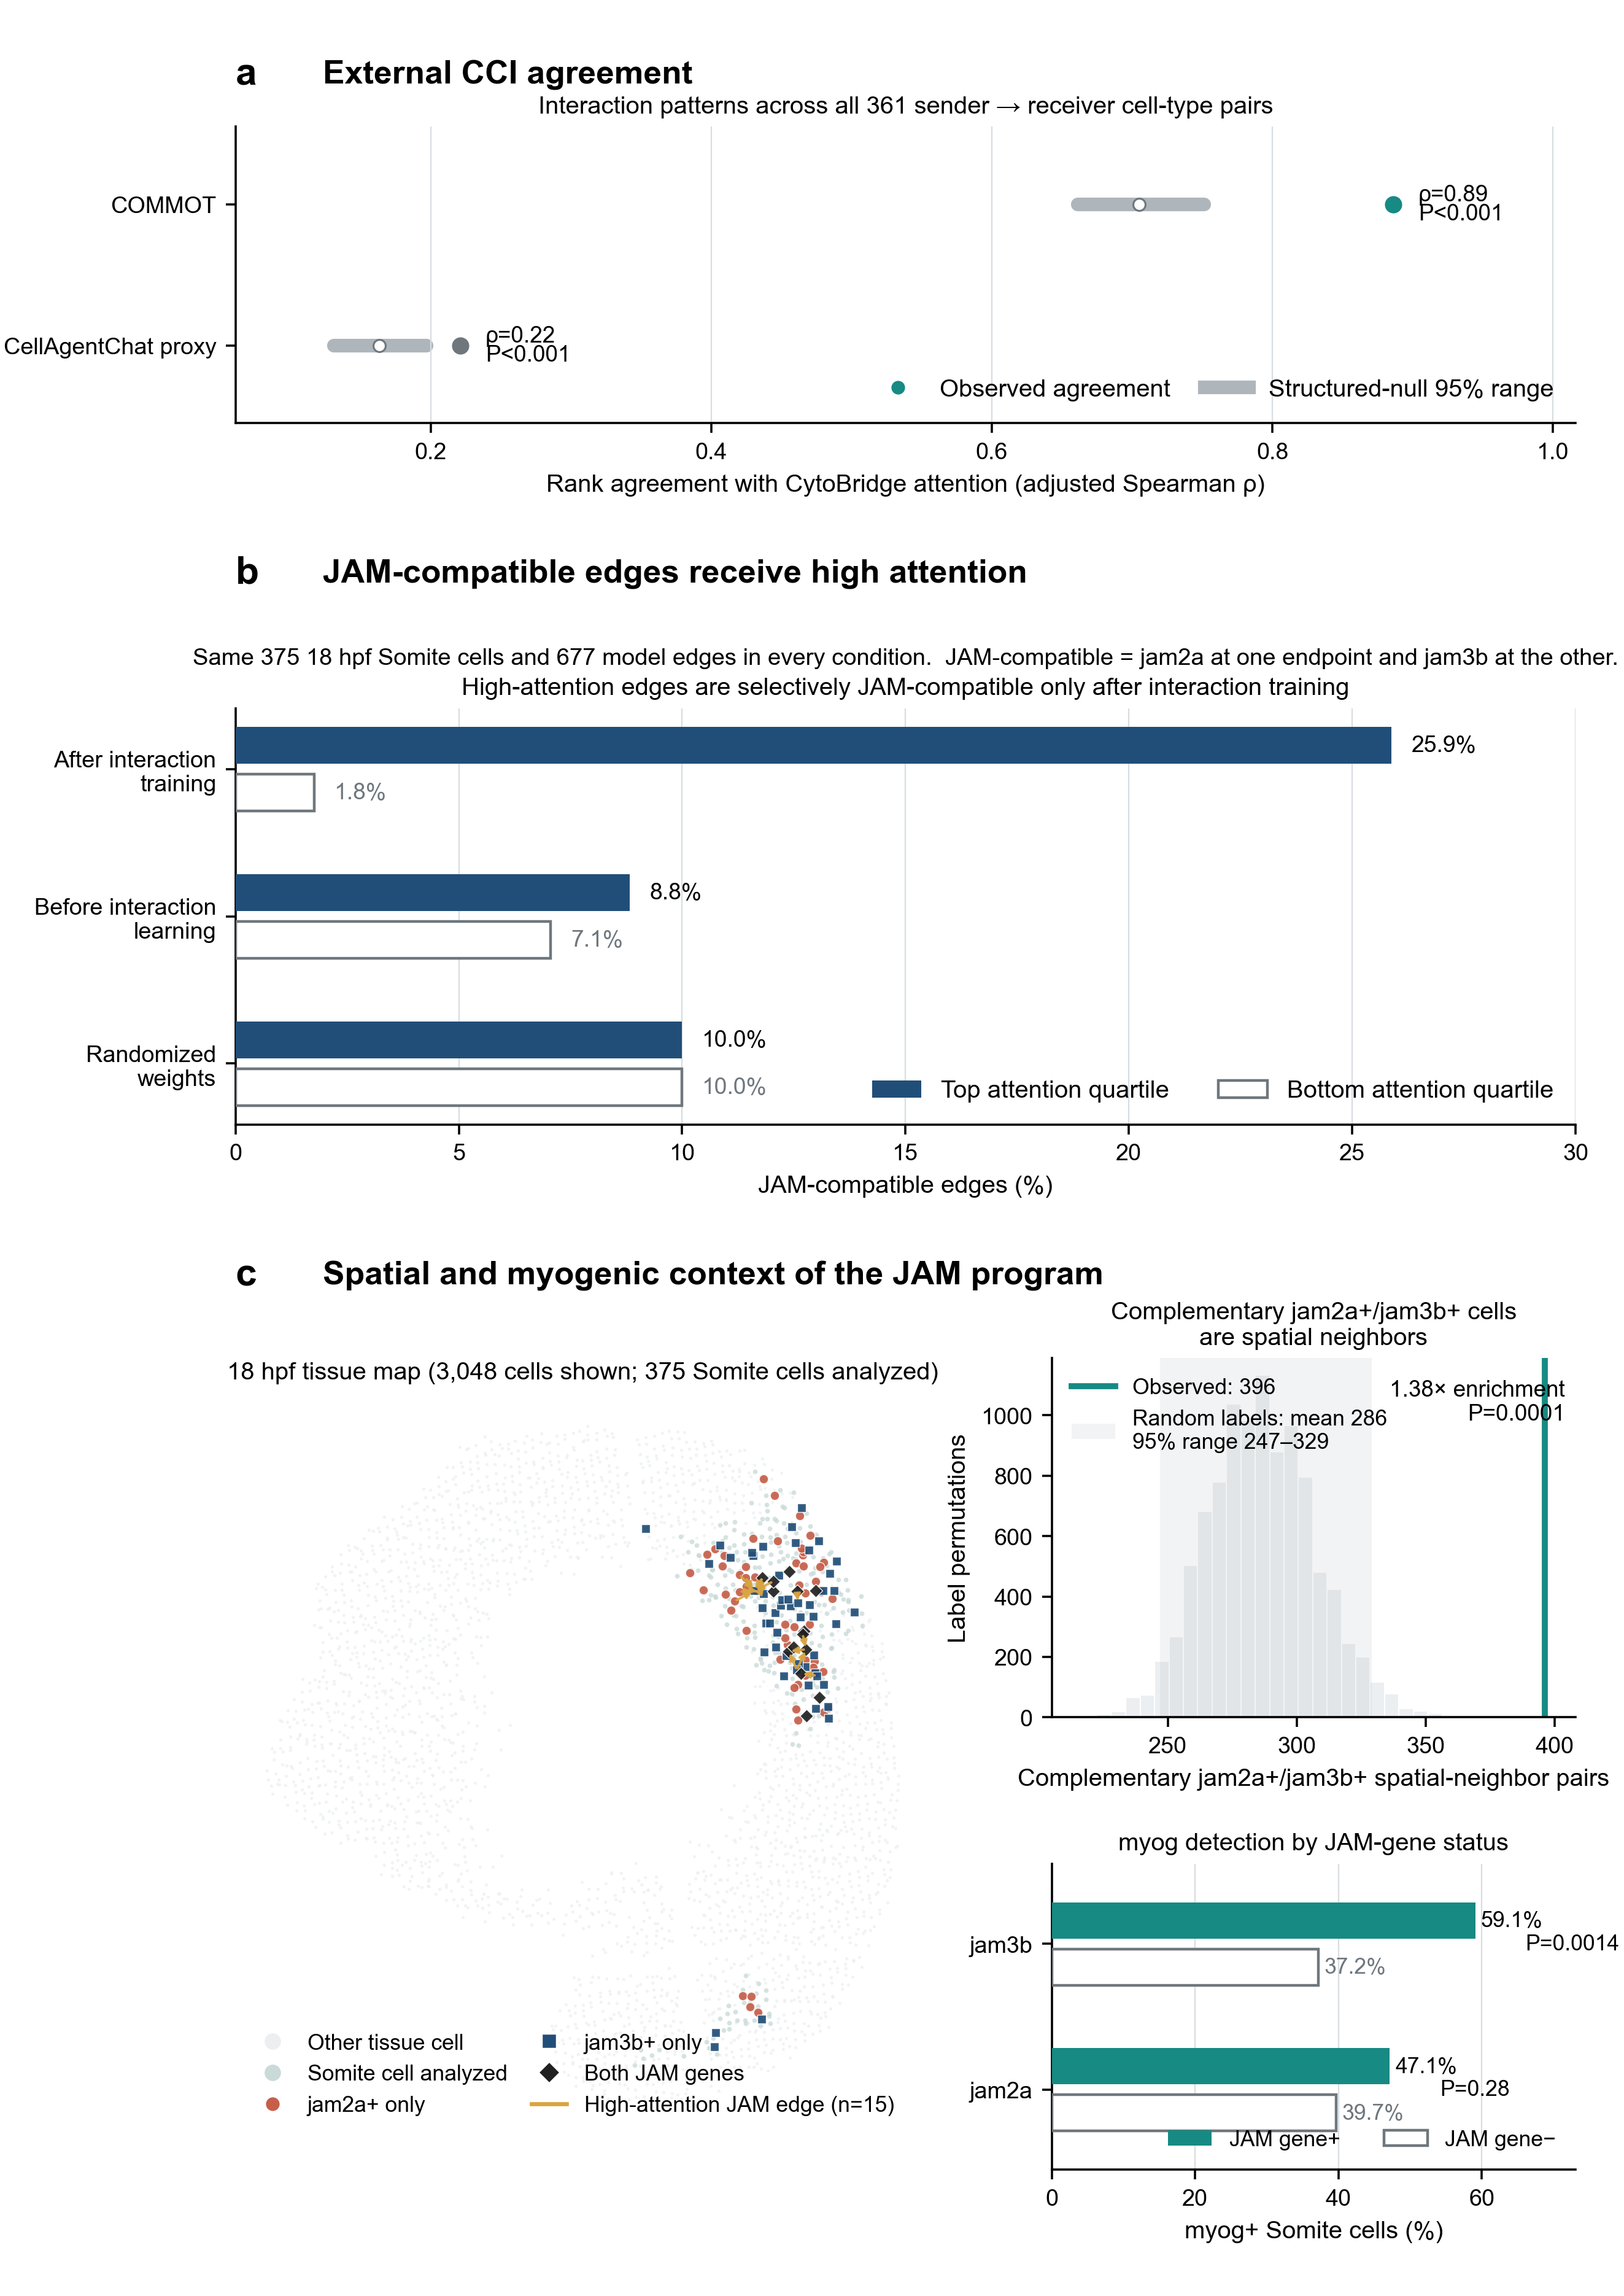

{'tables': {'external_agreement': True,
  'jam_quartiles': True,
  'somite_ranks': True,
  'myog_detection': True,
  'spatial_null': True},
 'pdf': True,
 'png': True}

In [3]:
table_paths = write_zebrafish_attention_tables(results, output_dir)
pdf_path, png_path = plot_zebrafish_attention(results, output_dir)
display(Image(filename=str(png_path), width=700))
{
    "tables": {name: path.is_file() for name, path in table_paths.items()},
    "pdf": pdf_path.is_file(),
    "png": png_path.is_file(),
}
